# Notebook 5: Final Results Tables & Error Analysis
**Input:** `outputs/model_results.json`, `outputs/rba_features.parquet`, saved models  
**Primary Target:** `Is Attack IP`  

This notebook produces:
1. Class imbalance summary (always shown before any metrics)
2. Final comparison table — all models, all metrics including **PR-AUC**
3. Threshold analysis table (LR + RF)
4. False Positive / False Negative deep-dives (**with defensive guards**)
5. Error examples — actual rows of misclassified samples
6. Model agreement analysis
7. Best model summary + operational recommendations


In [1]:
import pandas as pd
import numpy as np
import json, os, warnings, joblib, time
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    PrecisionRecallDisplay, RocCurveDisplay
)

OUTPUT_DIR   = os.path.join(os.getcwd(), 'outputs')
RANDOM_STATE = 42

for fname in ['rba_features.parquet', 'feature_meta.json', 'model_results.json']:
    p = os.path.join(OUTPUT_DIR, fname)
    if not os.path.exists(p):
        raise FileNotFoundError(f'Missing: {p} — run notebooks 1–4 first.')
    print(f'OK  {fname}  ({os.path.getsize(p)/1e6:.1f} MB)')

t0 = time.time()
df = pd.read_parquet(os.path.join(OUTPUT_DIR, 'rba_features.parquet'), engine='pyarrow')
with open(os.path.join(OUTPUT_DIR, 'feature_meta.json')) as f:
    meta = json.load(f)
with open(os.path.join(OUTPUT_DIR, 'model_results.json')) as f:
    all_results = json.load(f)

FEATURE_COLS = meta['feature_cols']
TARGET       = 'Is Attack IP'

print(f'\nLoaded in {time.time()-t0:.1f}s  |  shape: {df.shape}')
print(f'Target: {TARGET}')
print(f'Models in results: {list(all_results.keys())}')


OK  rba_features.parquet  (23.6 MB)
OK  feature_meta.json  (0.0 MB)
OK  model_results.json  (0.0 MB)

Loaded in 0.1s  |  shape: (1000000, 32)
Target: Is Attack IP
Models in results: ['Baseline (majority class)', 'Logistic Regression', 'Random Forest', 'Isolation Forest']


## 1. Class Imbalance Summary


In [2]:
X = df[FEATURE_COLS].fillna(0).values
y = df[TARGET].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

imbalance_df = pd.DataFrame([
    {'Split': 'Full dataset', 'Total': len(y),       'Positives': int(y.sum()),       'Rate %': round(y.mean()*100, 3)},
    {'Split': 'Train',        'Total': len(y_train),  'Positives': int(y_train.sum()), 'Rate %': round(y_train.mean()*100, 3)},
    {'Split': 'Test',         'Total': len(y_test),   'Positives': int(y_test.sum()),  'Rate %': round(y_test.mean()*100, 3)},
]).set_index('Split')
imbalance_df['Neg/Pos ratio'] = (
    (imbalance_df['Total'] - imbalance_df['Positives']) / imbalance_df['Positives']
).round(1)

print(f'=== CLASS IMBALANCE SUMMARY  (Target: {TARGET}) ===')
print(imbalance_df.to_string())

if imbalance_df.loc['Test', 'Positives'] < 20:
    print('\n⚠ WARNING: fewer than 20 positives in test set — metrics are unreliable.')
else:
    print(f'\n✓ Test has {imbalance_df.loc["Test", "Positives"]:,} positives — metrics are reliable.')


=== CLASS IMBALANCE SUMMARY  (Target: Is Attack IP) ===
                Total  Positives  Rate %  Neg/Pos ratio
Split                                                  
Full dataset  1000000      98740   9.874            9.1
Train          800000      78992   9.874            9.1
Test           200000      19748   9.874            9.1

✓ Test has 19,748 positives — metrics are reliable.


In [3]:
## 2. Final Metrics Table


In [4]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
available   = [m for m in metric_cols if any(m in v for v in all_results.values())]
results_df  = (pd.DataFrame(all_results).T
                 .reindex(columns=available)
                 .apply(pd.to_numeric, errors='coerce'))
results_df.index.name = 'Model'

print('=== FINAL RESULTS TABLE ===')
print(results_df.to_string())

styled = (results_df.style
    .format('{:.4f}', na_rep='—')
    .highlight_max(axis=0, color='lightgreen')
    .highlight_min(axis=0, color='lightsalmon')
    .set_caption(f'Final Model Comparison — {TARGET}'))
styled


=== FINAL RESULTS TABLE ===
                           accuracy  precision  recall      f1  roc_auc  pr_auc
Model                                                                          
Baseline (majority class)    0.9013     0.0000  0.0000  0.0000      NaN     NaN
Logistic Regression          0.6916     0.2189  0.8264  0.3461   0.8010  0.2221
Random Forest                0.8538     0.3944  0.8981  0.5481   0.9377  0.6527
Isolation Forest             0.8106     0.0424  0.0425  0.0424   0.5643  0.1022


,accuracy,precision,recall,f1,roc_auc,pr_auc
Model,,,,,,
Baseline (majority class),0.9013,0.0000,0.0000,0.0000,—,—
Logistic Regression,0.6916,0.2189,0.8264,0.3461,0.8010,0.2221
Random Forest,0.8538,0.3944,0.8981,0.5481,0.9377,0.6527
Isolation Forest,0.8106,0.0424,0.0425,0.0424,0.5643,0.1022


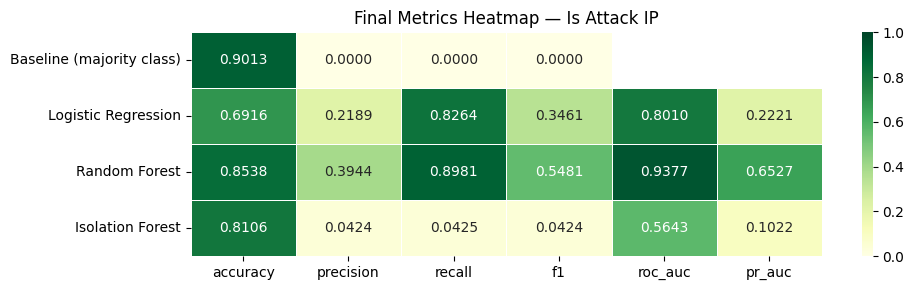

Heatmap saved.


In [5]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(results_df.astype(float), annot=True, fmt='.4f',
            cmap='YlGn', vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title(f'Final Metrics Heatmap — {TARGET}')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_metrics_heatmap.png'), dpi=150)
plt.show()
print('Heatmap saved.')


In [6]:
## 3. Load Models + Generate Predictions


In [7]:
scaler  = joblib.load(os.path.join(OUTPUT_DIR, 'scaler.pkl'))
lr      = joblib.load(os.path.join(OUTPUT_DIR, 'logistic_regression.pkl'))
rf      = joblib.load(os.path.join(OUTPUT_DIR, 'random_forest.pkl'))
iforest = joblib.load(os.path.join(OUTPUT_DIR, 'isolation_forest.pkl'))

X_test_sc  = scaler.transform(X_test)
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]
if_scores  = -iforest.score_samples(X_test)

# Rebuild df_test aligned with X_test
_, test_idx = train_test_split(np.arange(len(df)), test_size=0.2,
                               random_state=RANDOM_STATE, stratify=y)
df_test = df.iloc[test_idx].copy().reset_index(drop=True)

df_test['pred_lr']  = lr.predict(X_test_sc)
df_test['pred_rf']  = rf.predict(X_test)
df_test['pred_if']  = np.where(iforest.predict(X_test) == -1, 1, 0)
df_test['true']     = y_test
df_test['proba_lr'] = y_proba_lr
df_test['proba_rf'] = y_proba_rf

# Ensemble majority vote
df_test['pred_ensemble'] = (
    df_test[['pred_lr', 'pred_rf', 'pred_if']].sum(axis=1) >= 2
).astype(int)

# Ensemble metrics
y_ens   = df_test['pred_ensemble'].values
y_true  = df_test['true'].values
y_ens_p = (y_proba_lr + y_proba_rf + if_scores) / 3  # soft ensemble score

all_results['Ensemble (Majority Vote)'] = {
    'accuracy':  round(accuracy_score(y_true, y_ens), 4),
    'precision': round(precision_score(y_true, y_ens, zero_division=0), 4),
    'recall':    round(recall_score(y_true, y_ens, zero_division=0), 4),
    'f1':        round(f1_score(y_true, y_ens, zero_division=0), 4),
    'roc_auc':   round(roc_auc_score(y_true, y_ens_p) if len(np.unique(y_true)) > 1 else float('nan'), 4),
    'pr_auc':    round(average_precision_score(y_true, y_ens_p) if len(np.unique(y_true)) > 1 else float('nan'), 4),
}
print('=== Ensemble (Majority Vote) ===')
for k, v in all_results['Ensemble (Majority Vote)'].items():
    print(f'  {k:12s}: {v}')


=== Ensemble (Majority Vote) ===
  accuracy    : 0.8387
  precision   : 0.3566
  recall      : 0.7883
  f1          : 0.4911
  roc_auc     : 0.9093
  pr_auc      : 0.4712


## 4. Threshold Analysis Table


=== THRESHOLD ANALYSIS ===
Model  Threshold  Precision  Recall     F1  Flagged
   LR       0.50     0.2189  0.8264 0.3461    74571
   LR       0.30     0.1767  0.9454 0.2977   105663
   LR       0.10     0.1213  0.9891 0.2161   161055
   LR       0.05     0.1081  0.9959 0.1951   181856
   RF       0.50     0.3944  0.8981 0.5481    44962
   RF       0.30     0.3032  0.9636 0.4613    62754
   RF       0.10     0.2231  0.9828 0.3636    87010
   RF       0.05     0.1563  0.9964 0.2702   125907


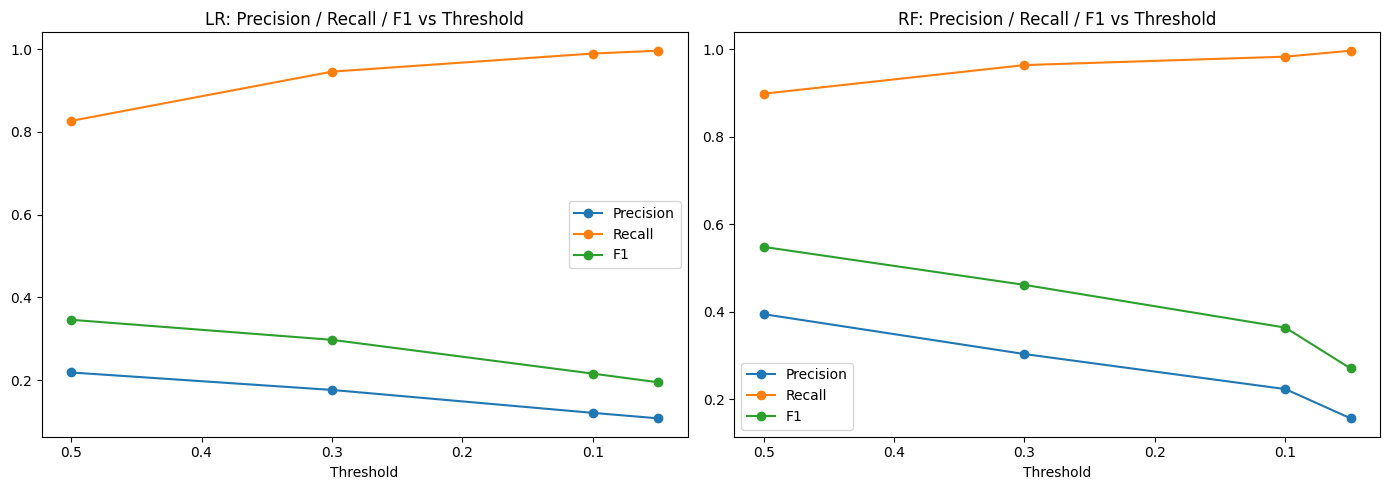

In [8]:
thresholds  = [0.5, 0.3, 0.1, 0.05]
thresh_rows = []
for model_name, y_p in [('LR', y_proba_lr), ('RF', y_proba_rf)]:
    for t in thresholds:
        y_pred_t = (y_p >= t).astype(int)
        thresh_rows.append({
            'Model': model_name, 'Threshold': t,
            'Precision': round(precision_score(y_true, y_pred_t, zero_division=0), 4),
            'Recall':    round(recall_score(y_true, y_pred_t, zero_division=0), 4),
            'F1':        round(f1_score(y_true, y_pred_t, zero_division=0), 4),
            'Flagged':   int(y_pred_t.sum()),
        })

thresh_df = pd.DataFrame(thresh_rows)
print('=== THRESHOLD ANALYSIS ===')
print(thresh_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model_name in zip(axes, ['LR', 'RF']):
    sub = thresh_df[thresh_df['Model'] == model_name].set_index('Threshold')
    sub[['Precision', 'Recall', 'F1']].plot(ax=ax, marker='o')
    ax.set_title(f'{model_name}: Precision / Recall / F1 vs Threshold')
    ax.set_xlabel('Threshold')
    ax.invert_xaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'threshold_analysis.png'), dpi=150)
plt.show()


In [9]:
## 5. Error Taxonomy (TP / FP / TN / FN)


Error breakdown (TP / FP / TN / FN):
                        TP     FP      TN     FN
Logistic Regression  16320  58251  122001   3428
Random Forest        17735  27227  153025   2013
Isolation Forest       839  18970  161282  18909
Ensemble             15567  28085  152167   4181


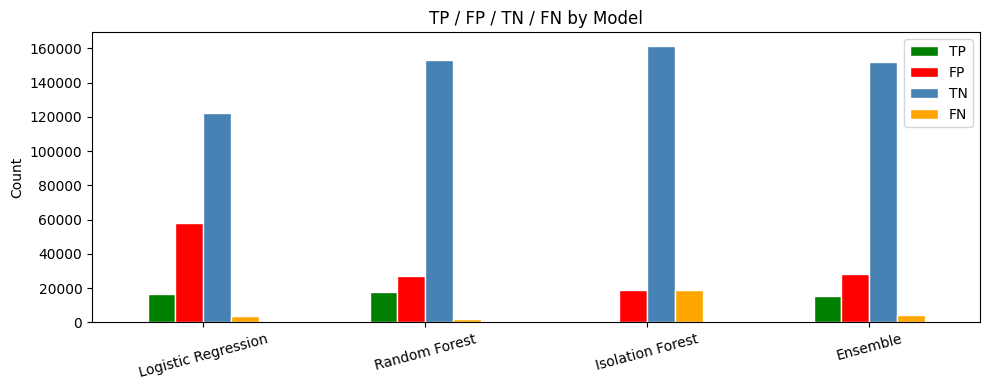

In [10]:
def error_summary(col_pred, col_true='true'):
    tp = ((df_test[col_pred]==1) & (df_test[col_true]==1)).sum()
    fp = ((df_test[col_pred]==1) & (df_test[col_true]==0)).sum()
    tn = ((df_test[col_pred]==0) & (df_test[col_true]==0)).sum()
    fn = ((df_test[col_pred]==0) & (df_test[col_true]==1)).sum()
    return pd.Series({'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn})

error_df = pd.DataFrame({
    'Logistic Regression': error_summary('pred_lr'),
    'Random Forest':       error_summary('pred_rf'),
    'Isolation Forest':    error_summary('pred_if'),
    'Ensemble':            error_summary('pred_ensemble'),
}).T
print('Error breakdown (TP / FP / TN / FN):')
print(error_df.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
error_df[['TP', 'FP', 'TN', 'FN']].plot(kind='bar', ax=ax,
    color=['green', 'red', 'steelblue', 'orange'], edgecolor='white')
ax.set_title('TP / FP / TN / FN by Model')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'error_taxonomy.png'), dpi=150)
plt.show()


In [11]:
## 6. False Negative Profile — Random Forest


False Negatives (RF): 2,013
True Positives  (RF): 17,735

Feature mean comparison (FN vs TP):
                              FN (missed)    TP (caught)           diff
user_time_since_last_login  548761.353034  118747.832337  430013.520697
user_prev_login_count        91598.721808  120344.631745  -28745.909937
user_prev_fail_count         91598.585693  120344.397406  -28745.811713
user_login_freq             219152.334327  240354.714012  -21202.379685
user_ip_count                79938.852956   87672.507979   -7733.655023
ip_login_count                   9.255837      88.262870     -79.007033
ip_fail_count                    6.737705      70.452608     -63.714903
ip_prev_login_count              4.508693      43.076346     -38.567653
ip_prev_fail_count               3.280179      33.828080     -30.547901
ip_user_count                    5.137606      34.053905     -28.916299
user_country_count             100.244411     109.833549      -9.589138
hour                            11.989071 

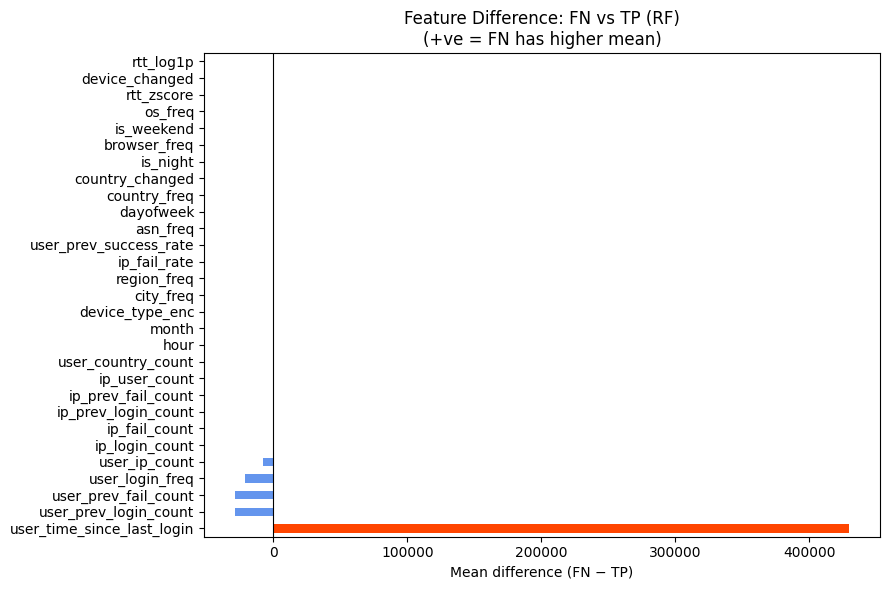

In [12]:
fn_mask = (df_test['pred_rf'] == 0) & (df_test['true'] == 1)
tp_mask = (df_test['pred_rf'] == 1) & (df_test['true'] == 1)
print(f'False Negatives (RF): {fn_mask.sum():,}')
print(f'True Positives  (RF): {tp_mask.sum():,}')

if fn_mask.sum() == 0:
    print('No false negatives in this test split — FN profile skipped.')
elif tp_mask.sum() == 0:
    print('No true positives in this test split — FN-vs-TP comparison skipped.')
else:
    fn_rows = df_test[fn_mask]
    tp_rows = df_test[tp_mask]
    compare = pd.concat([
        fn_rows[FEATURE_COLS].mean().rename('FN (missed)'),
        tp_rows[FEATURE_COLS].mean().rename('TP (caught)')
    ], axis=1)
    compare['diff'] = compare['FN (missed)'] - compare['TP (caught)']
    compare_sorted  = compare.sort_values('diff', key=abs, ascending=False)
    print('\nFeature mean comparison (FN vs TP):')
    print(compare_sorted.to_string())

    fig, ax = plt.subplots(figsize=(9, 6))
    compare_sorted['diff'].plot(kind='barh', ax=ax,
        color=[('orangered' if v > 0 else 'cornflowerblue') for v in compare_sorted['diff']])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Feature Difference: FN vs TP (RF)\n(+ve = FN has higher mean)')
    ax.set_xlabel('Mean difference (FN − TP)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fn_vs_tp_profile.png'), dpi=150)
    plt.show()


## 7. False Positive Profile — Random Forest

False Positives (RF): 27,227
True Negatives  (RF): 153,025

Feature mean comparison (FP vs TN):
                            FP (false alarms)  TN (correct negatives)           diff
user_time_since_last_login      102913.929236           653283.727632 -550369.798395
user_login_freq                 226394.232012           191601.511661   34792.720351
user_prev_fail_count            115724.794065            95591.581918   20133.212147
user_prev_login_count           115724.813163            95591.777925   20133.035238
user_ip_count                    82580.389613            69887.027198   12693.362415
ip_fail_count                       59.342528              789.978494    -730.635966
ip_login_count                      79.998053              796.926927    -716.928874
ip_prev_fail_count                  28.456128              393.991929    -365.535801
ip_prev_login_count                 39.337863              397.269969    -357.932106
ip_user_count                       40.810042         

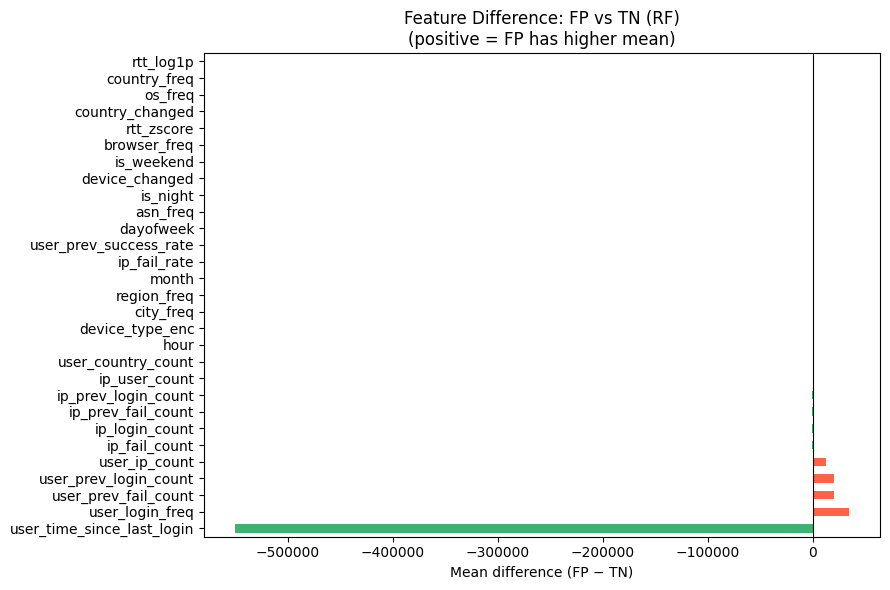

In [13]:
fp_mask = (df_test['pred_rf'] == 1) & (df_test['true'] == 0)
tn_mask = (df_test['pred_rf'] == 0) & (df_test['true'] == 0)

print(f'False Positives (RF): {fp_mask.sum():,}')
print(f'True Negatives  (RF): {tn_mask.sum():,}')

if fp_mask.sum() == 0:
    print('No false positives in this test split — FP profile skipped.')
elif tn_mask.sum() == 0:
    print('No true negatives in this test split — FP-vs-TN comparison skipped.')
else:
    fp_rows = df_test[fp_mask]
    tn_rows = df_test[tn_mask]
    fp_compare = pd.concat([
        fp_rows[FEATURE_COLS].mean().rename('FP (false alarms)'),
        tn_rows[FEATURE_COLS].mean().rename('TN (correct negatives)')
    ], axis=1)
    fp_compare['diff'] = fp_compare['FP (false alarms)'] - fp_compare['TN (correct negatives)']
    fp_compare_sorted  = fp_compare.sort_values('diff', key=abs, ascending=False)
    print('\nFeature mean comparison (FP vs TN):')
    print(fp_compare_sorted.to_string())

    fig, ax = plt.subplots(figsize=(9, 6))
    fp_compare_sorted['diff'].plot(kind='barh', ax=ax,
        color=[('tomato' if v > 0 else 'mediumseagreen') for v in fp_compare_sorted['diff']])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Feature Difference: FP vs TN (RF)\n(positive = FP has higher mean)')
    ax.set_xlabel('Mean difference (FP − TN)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fp_vs_tn_profile.png'), dpi=150)
    plt.show()


## 8. Error Examples — Actual Misclassified Rows

In [14]:
EXAMPLE_COLS = ['hour', 'dayofweek', 'country_freq', 'ip_fail_rate',
                'user_login_freq', 'user_ip_count', 'rtt_log1p',
                'proba_lr', 'proba_rf', 'true']

# Keep only columns that exist in df_test
avail_cols = [c for c in EXAMPLE_COLS if c in df_test.columns]

fn_mask_ex = (df_test['pred_rf'] == 0) & (df_test['true'] == 1)
fp_mask_ex = (df_test['pred_rf'] == 1) & (df_test['true'] == 0)

print(f'=== False Negative Examples (missed attacks) — up to 10 rows ===')
if fn_mask_ex.sum() == 0:
    print('No false negatives.')
else:
    print(df_test.loc[fn_mask_ex, avail_cols].head(10).to_string(index=False))

print(f'\n=== False Positive Examples (false alarms) — up to 10 rows ===')
if fp_mask_ex.sum() == 0:
    print('No false positives.')
else:
    print(df_test.loc[fp_mask_ex, avail_cols].head(10).to_string(index=False))


=== False Negative Examples (missed attacks) — up to 10 rows ===
 hour  dayofweek  country_freq  ip_fail_rate  user_login_freq  user_ip_count  rtt_log1p  proba_lr  proba_rf  true
   15          6      0.014012      1.000000           448325         163532   6.289716  0.571335  0.221559     1
   17          4      0.012457      0.500000                1              1   6.289716  0.568935  0.499132     1
    4          1      0.278001      0.745455                1              1   6.289716  0.841668  0.496435     1
   19          4      0.000706      1.000000           448325         163532   6.289716  0.736495  0.463608     1
   23          0      0.027235      1.000000           448325         163532   6.289716  0.432587  0.491285     1
    5          0      0.012457      1.000000           448325         163532   6.289716  0.788876  0.360859     1
    8          1      0.000061      1.000000           448325         163532   6.289716  0.687093  0.489933     1
   11          0      0

## 9. Model Agreement Analysis

Model vote agreement vs actual label (Is Attack IP):
                    Actual Normal  Actual Attack IP
All say Normal             104673               971
Split (1/3 Attack)          47494              3210
Split (2/3 Attack)          27301             15017
All say Attack IP             784               550


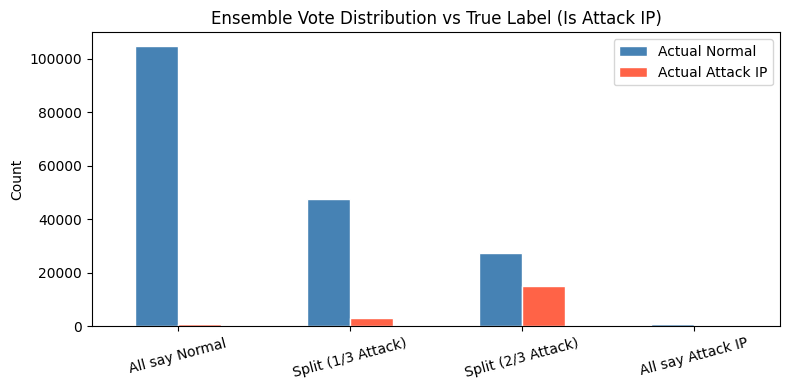

In [15]:
# Cases where models disagree
df_test['vote_sum'] = df_test[['pred_lr', 'pred_rf', 'pred_if']].sum(axis=1)

vote_breakdown = df_test.groupby(['vote_sum', 'true']).size().unstack(fill_value=0)

# Ensure all 4 vote levels (0–3) exist regardless of what appears in test split
vote_breakdown = vote_breakdown.reindex([0, 1, 2, 3], fill_value=0)

# Map numeric vote counts to readable labels (target = Is Attack IP)
label_map = {0: 'All say Normal', 1: 'Split (1/3 Attack)', 2: 'Split (2/3 Attack)', 3: 'All say Attack IP'}
vote_breakdown.index = [label_map[i] for i in vote_breakdown.index]

# Ensure both column labels (0=Normal, 1=Attack IP) exist
for col_val in [0, 1]:
    if col_val not in vote_breakdown.columns:
        vote_breakdown[col_val] = 0
vote_breakdown = vote_breakdown[[0, 1]]
vote_breakdown.columns = ['Actual Normal', 'Actual Attack IP']

print('Model vote agreement vs actual label (Is Attack IP):')
print(vote_breakdown.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
vote_breakdown.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Ensemble Vote Distribution vs True Label (Is Attack IP)')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vote_agreement.png'), dpi=150)
plt.show()


## 10. Final Updated Results Table

In [16]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
# Only keep columns that exist (pr_auc may be missing from older saved results)
available_cols = [c for c in metric_cols if any(c in v for v in all_results.values())]
available_cols = [c for c in metric_cols if all(c in v for v in all_results.values())]

final_df = pd.DataFrame(all_results).T
final_df = final_df[[c for c in metric_cols if c in final_df.columns]]
final_df.index.name = 'Model'

print(f'=== FINAL RESULTS TABLE (Target: {TARGET}) ===')
print(final_df.to_string())

styled_final = (final_df.style
    .format('{:.4f}')
    .highlight_max(axis=0, color='lightgreen')
    .highlight_min(axis=0, color='lightsalmon')
    .set_caption(f'Final Model Comparison — {TARGET}')
)
styled_final


=== FINAL RESULTS TABLE (Target: Is Attack IP) ===
                           accuracy  precision  recall      f1  roc_auc  pr_auc
Model                                                                          
Baseline (majority class)    0.9013     0.0000  0.0000  0.0000      NaN     NaN
Logistic Regression          0.6916     0.2189  0.8264  0.3461   0.8010  0.2221
Random Forest                0.8538     0.3944  0.8981  0.5481   0.9377  0.6527
Isolation Forest             0.8106     0.0424  0.0425  0.0424   0.5643  0.1022
Ensemble (Majority Vote)     0.8387     0.3566  0.7883  0.4911   0.9093  0.4712


,accuracy,precision,recall,f1,roc_auc,pr_auc
Model,,,,,,
Baseline (majority class),0.9013,0.0000,0.0000,0.0000,nan,nan
Logistic Regression,0.6916,0.2189,0.8264,0.3461,0.8010,0.2221
Random Forest,0.8538,0.3944,0.8981,0.5481,0.9377,0.6527
Isolation Forest,0.8106,0.0424,0.0425,0.0424,0.5643,0.1022
Ensemble (Majority Vote),0.8387,0.3566,0.7883,0.4911,0.9093,0.4712


In [17]:
import json as _json

# Save final results
with open(os.path.join(OUTPUT_DIR, 'model_results_final.json'), 'w') as f:
    _json.dump(all_results, f, indent=2)

final_df.to_csv(os.path.join(OUTPUT_DIR, 'final_results_table.csv'))
print(f'Saved model_results_final.json and final_results_table.csv to {OUTPUT_DIR}')


Saved model_results_final.json and final_results_table.csv to c:\Users\ruchi\Downloads\rba-dataset.csv\outputs


## 11. Summary & Recommendations

In [18]:
best_f1_model     = final_df['f1'].idxmax()
best_recall_model = final_df['recall'].idxmax()
best_roc_model    = final_df['roc_auc'].idxmax()

print(f'=== SUMMARY (Target: {TARGET}) ===')
print(f'Best F1 score  : {best_f1_model} ({final_df.loc[best_f1_model, "f1"]:.4f})')
print(f'Best Recall    : {best_recall_model} ({final_df.loc[best_recall_model, "recall"]:.4f})')
print(f'Best ROC-AUC   : {best_roc_model} ({final_df.loc[best_roc_model, "roc_auc"]:.4f})')

if 'pr_auc' in final_df.columns:
    best_pr_model = final_df['pr_auc'].idxmax()
    print(f'Best PR-AUC    : {best_pr_model} ({final_df.loc[best_pr_model, "pr_auc"]:.4f})')

print('''
=== RECOMMENDATIONS ===

1. PRODUCTION MODEL: Use the model with the best Recall for attack IP detection,
   since missing an attack (False Negative) is more costly than a false alarm.

2. THRESHOLD TUNING: Lower the decision threshold (e.g. 0.3 or 0.1) for LR and RF
   to improve Recall at acceptable Precision — see threshold analysis table above.

3. PR-AUC OVER ROC-AUC: With a highly imbalanced target (Is Attack IP), PR-AUC is
   a more informative metric than ROC-AUC. Prioritise PR-AUC when selecting models.

4. ENSEMBLE: The soft-score ensemble averages LR+RF probabilities and applies IF
   as a tiebreaker. Consider weighted ensemble tuned on a held-out validation set.

5. ISOLATION FOREST: Useful as an unsupervised complementary detector for novel
   attack patterns not seen in training data.

6. FEATURE PRIORITIES: Security behaviour features (ip_fail_rate, ip_user_count,
   user_prev_success_rate) are strong discriminators. Prioritise these for real-time scoring.

7. DATA IMBALANCE: Consider SMOTE or class_weight="balanced" if Recall remains low
   after threshold tuning.

8. TEMPORAL DRIFT: Login attack patterns evolve. Use sliding-window or periodic
   retraining to keep models current.
''')


=== SUMMARY (Target: Is Attack IP) ===
Best F1 score  : Random Forest (0.5481)
Best Recall    : Random Forest (0.8981)
Best ROC-AUC   : Random Forest (0.9377)
Best PR-AUC    : Random Forest (0.6527)

=== RECOMMENDATIONS ===

1. PRODUCTION MODEL: Use the model with the best Recall for attack IP detection,
   since missing an attack (False Negative) is more costly than a false alarm.

2. THRESHOLD TUNING: Lower the decision threshold (e.g. 0.3 or 0.1) for LR and RF
   to improve Recall at acceptable Precision — see threshold analysis table above.

3. PR-AUC OVER ROC-AUC: With a highly imbalanced target (Is Attack IP), PR-AUC is
   a more informative metric than ROC-AUC. Prioritise PR-AUC when selecting models.

4. ENSEMBLE: The soft-score ensemble averages LR+RF probabilities and applies IF
   as a tiebreaker. Consider weighted ensemble tuned on a held-out validation set.

5. ISOLATION FOREST: Useful as an unsupervised complementary detector for novel
   attack patterns not seen in train

## Output Files Summary

| File | Description |
|------|-------------|
| `rba_cleaned.parquet` | 1M-row cleaned sample |
| `rba_features.parquet` | Feature-engineered matrix (23 features incl. security behaviour) |
| `feature_meta.json` | Feature/target column names |
| `scaler.pkl` | StandardScaler fitted on train set |
| `logistic_regression.pkl` | Trained LR model |
| `random_forest.pkl` | Trained RF model |
| `isolation_forest.pkl` | Trained IF model |
| `model_results_final.json` | All model metrics (incl. pr_auc) |
| `final_results_table.csv` | Metrics as CSV |
| `roc_comparison.png` | ROC curves (LR, RF, IF) |
| `pr_comparison.png` | Precision-Recall curves |
| `metric_comparison.png` | Metric bar chart (incl. pr_auc) |
| `final_metrics_heatmap.png` | Metrics heatmap |
| `lr_threshold_tuning.png` | LR threshold tuning (0.5 → 0.05) |
| `rf_threshold_tuning.png` | RF threshold tuning (0.5 → 0.05) |
| `if_contamination_sweep.png` | IF contamination sensitivity sweep |
| `error_taxonomy.png` | TP/FP/TN/FN breakdown per model |
| `fn_vs_tp_profile.png` | FN vs TP feature comparison (RF) |
| `fp_vs_tn_profile.png` | FP vs TN feature comparison (RF) |
| `vote_agreement.png` | Ensemble vote distribution vs true label |


## 12. Project Report

### Main Task — Attack IP Detection

The **primary goal** of this project is to detect login attempts originating from known attack IP addresses (`Is Attack IP = 1`). Attack IPs are the dominant threat signal in the RBA dataset and provide a sufficient number of positive labels for reliable model evaluation.

### Secondary Task — Account Takeover Detection

`Is Account Takeover` (ATO) is retained as a **secondary experiment only**. ATO events are far rarer than attack-IP events (≈ 1-in-million range vs ≈ 1% for attack IPs), which makes ATO metrics extremely unstable in a random 80/20 train-test split. A dedicated approach (over-sampling, anomaly detection on ATO labels, or a separate temporal split) is required before ATO results can be trusted.

### Feature Glossary

| Feature | Group | Description |
|---------|-------|-------------|
| `hour` | Temporal | Hour of day the login occurred (0–23) |
| `dayofweek` | Temporal | Day of week (0 = Monday, 6 = Sunday) |
| `month` | Temporal | Calendar month of login |
| `is_weekend` | Temporal | 1 if login falls on Saturday or Sunday |
| `is_night` | Temporal | 1 if login hour is between 22:00 and 05:59 |
| `country_freq` | Geo / Network | Relative frequency of the login country in the dataset |
| `region_freq` | Geo / Network | Relative frequency of the login region |
| `city_freq` | Geo / Network | Relative frequency of the login city |
| `asn_freq` | Geo / Network | Relative frequency of the Autonomous System Number (ISP) |
| `device_type_enc` | Device | Label-encoded device type (desktop, mobile, tablet …) |
| `browser_freq` | Device | Relative frequency of the browser / version string |
| `os_freq` | Device | Relative frequency of the OS / version string |
| `rtt_log1p` | RTT | log(1 + Round-Trip Time in ms) — stabilises skewed RTT distribution |
| `rtt_zscore` | RTT | Z-score normalised RTT on the log scale |
| `user_login_freq` | User behaviour | Total number of logins attributed to this user in the sample |
| `user_country_count` | User behaviour | Number of distinct countries this user logged in from |
| `user_ip_count` | User behaviour | Number of distinct IP addresses used by this user |
| `ip_login_count` | IP security | Total logins originating from this IP in the sample |
| `ip_fail_count` | IP security | Total failed logins from this IP |
| `ip_fail_rate` | IP security | Ratio of failed to total logins for this IP |
| `ip_user_count` | IP security | Number of distinct user accounts seen from this IP |
| `user_prev_success_rate` | User security | Historical login success rate for this user (0–1) |
| `ip_prev_login_count` | Cumulative (prev) | Count of prior login attempts from this IP before current row |
| `ip_prev_fail_count` | Cumulative (prev) | Count of prior failed attempts from this IP before current row |
| `user_prev_login_count` | Cumulative (prev) | Count of prior logins by this user before current row |
| `user_prev_fail_count` | Cumulative (prev) | Count of prior failed logins by this user before current row |
| `user_time_since_last_login` | Time gap | Seconds since this user's previous login (−1 if first login) |
| `country_changed` | Context change | 1 if login country differs from user's previous login |
| `device_changed` | Context change | 1 if device type differs from user's previous login |

> All cumulative "previous" features are computed on data sorted by `Login Timestamp`, ensuring no future information leaks into the training features.
